# Heat Loss Estimation

## Objective
Estimate the heat loss coefficient based on indoor and outdoor measurements.

## Dataset
- Multiple temperature sensors: 2 indoor sensors (living zones) and 2 outdoor sensors (north vs south exposure)
- Time-series data from Home Assistant export

## Key Questions
- Estimate heat loss coefficient (UA value)
- Estimate the cooling slope (°C/hour)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Get date after all sensors are fully operational
min_date = pd.to_datetime('2026-02-22 17:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[df_raw['time'] > min_date]

## 1. Simplified Cooling Rate Estimation

As a first step, we estimate the cooling behavior of the building using a simple empirical approach.

During nighttime, external influences such as solar radiation are minimal, and HVAC operation is typically reduced. Under these conditions, the indoor temperature evolution can be approximated as:

$T_{in}(t) \approx a + b \cdot t$

where:
- b (°C/hour) represents the cooling rate
- b is expected to be negative, indicating heat loss

To estimate this, we:
- filter nighttime periods
- perform linear regression on indoor temperature vs time

This provides a first-order approximation of how quickly each zone loses heat.

In [4]:
def compute_cooling_rate(df, column, start="01:00", end="06:00"):
    df = df.copy()
    df = df.set_index(['time'])
    results = []
    for day, group in df.groupby(df.index.date):
        night_time = group.between_time(start, end)
        if len(night_time) < 4:
            continue
        
        # Time in hours
        t = (night_time.index - night_time.index[0]).total_seconds() / 3600
        t = t.values.reshape(-1, 1)
        T = night_time[column].values.reshape(-1, 1)

        model = LinearRegression()
        model.fit(t, T)
        
        slope = model.coef_[0][0]
        r2 = model.score(t, T)

        results.append({
            "date": pd.Timestamp(day),
            "cooling_rate_C_per_h": slope,
            "r2": r2
        })

    return pd.DataFrame(results).set_index("date")

In [5]:
# Call method for living room (facing North)
living_room_rate = compute_cooling_rate(df_filtered, "temp_salon_c", start="01:00", end="06:00")
living_room_rate.describe()

,cooling_rate_C_per_h,r2
count,10.000000,10.000000
mean,-0.104543,0.957694
std,0.027706,0.043567
min,-0.139429,0.871035
25%,-0.126857,0.954981
50%,-0.104714,0.976826
75%,-0.087143,0.985111
max,-0.059429,0.991823


In [6]:
# Call method for bedroom (facing South)
bedroom_rate = compute_cooling_rate(df_filtered, "temp_kids_c", start="01:00", end="06:00")
bedroom_rate.describe()

,cooling_rate_C_per_h,r2
count,10.000000,10.000000
mean,-0.097543,0.967129
std,0.023881,0.022443
min,-0.137429,0.923751
25%,-0.113929,0.958838
50%,-0.089143,0.969200
75%,-0.084071,0.980916
max,-0.067429,0.996248


## Comments on Estimated Cooling Rate based on Simplified Approach

**Living Room**
- mean slope = -0.1045 $^oC/h$ → -0.10$^οC/h$
- mean $R^2 = 0.957$

**Bedroom**
- mean slope = -0.0975 $^oC/h$ → -0.098  $^oC/h$
- mean $R^2 = 0.967$

Difference in mean slope $\approx 6\%$

High $R^2$ values indicate that: $T(t) \approx a + bt$ provides a good description of the thermal behavior during nighttime.
<br><br>
**Useful Insight**:
The north- and south-facing zones have very similar cooling rates.

This suggests that the daytime temperature difference is probably due to:

☀️ solar gain

and not by different heat loss rate over the two orientations.

## 2. First-Order Thermal Model Interpretation

The simplified cooling rate can be interpreted using a first-order thermal model:

$\frac{dT_{in}}{dt} = -k (T_{in} - T_{out}) + u(t)$

where:
- k (1/hour) is the thermal loss coefficient
- T_out is the outdoor temperature
- u(t) represents internal gains (heating, occupancy, appliances)

During nighttime, internal gains are assumed to be negligible (u(t) ≈ 0), leading to:

$\frac{dT_{in}}{dt} \approx -k \cdot (T_{in} - T_{out})$

This model allows us to relate the observed cooling rate to a physically meaningful parameter k, which describes how strongly the building exchanges heat with the environment.

A similar value of k across zones indicates a relatively uniform building envelope, while differences may reveal asymmetries in insulation, exposure, or usage.

In [7]:
def compute_normalized_cooling_rate(df, column_in, column_out,  start="01:00", end="06:00"):
    df = df.copy()
    df = df.set_index(['time'])
    results = []
    
    for day, group in df.groupby(df.index.date):
        night_time = group.between_time(start, end).dropna(subset=[column_in, column_out])
        if len(night_time) < 4:
            continue
        
        T_in = night_time[column_in].to_numpy(dtype=float)
        T_out = night_time[column_out].to_numpy(dtype=float)
        
        # χρόνος σε ώρες από την αρχή του παραθύρου
        t_hours = (night_time.index - night_time.index[0]).total_seconds() / 3600.0
        t_hours = np.asarray(t_hours, dtype=float)
        
        # dT/dt σε °C/h
        dT_dt = np.gradient(T_in, t_hours)

        # ΔΤ μέσα-έξω
        deltaT = T_in - T_out
        
        # Κόβουμε σημεία όπου ΔΤ είναι πολύ μικρό ή αρνητικό
        mask = deltaT > 0.5

        if mask.sum() < 3:
            continue
        
        k_values = -dT_dt[mask] / deltaT[mask]
        k = np.mean(k_values)
        
        results.append({
            "date": pd.Timestamp(day),
            "k_1_per_h": k,
            "tau_h": 1.0 / k if k > 0 else np.nan,
            "mean_deltaT": np.mean(deltaT[mask]),
            "mean_dTdt": np.mean(dT_dt[mask]),
            "n_points": int(mask.sum())
        })

    return pd.DataFrame(results).set_index("date")

In [8]:
north_k = compute_normalized_cooling_rate(
    df_filtered,
    column_in="temp_salon_c",
    column_out="temp_out_1_b_c",
    start="01:00",
    end="06:00"
)
north_mean = north_k['k_1_per_h'].mean()
north_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.011497,88.939550,9.000833,-0.104833,6.0
std,0.001764,14.275376,1.765984,0.031671,0.0
min,0.009022,72.606731,5.695000,-0.141667,6.0
25%,0.009991,76.900466,8.525833,-0.131667,6.0
50%,0.011664,85.914885,9.655000,-0.108750,6.0
75%,0.013004,100.269337,10.245833,-0.080625,6.0
max,0.013773,110.840398,10.578333,-0.055833,6.0


In [9]:
south_k = compute_normalized_cooling_rate(
    df_filtered,
    column_in="temp_kids_c",
    column_out="temp_out_2_n_c",
    start="01:00",
    end="06:00"
)
south_mean = south_k['k_1_per_h'].mean()
south_k.describe()

,k_1_per_h,tau_h,mean_deltaT,mean_dTdt,n_points
count,10.000000,10.000000,10.000000,10.000000,10.0
mean,0.010273,100.496416,9.440667,-0.097083,6.0
std,0.001855,19.599026,1.617870,0.024740,0.0
min,0.007373,80.568515,6.486667,-0.136667,6.0
25%,0.009017,84.116284,9.056667,-0.118750,6.0
50%,0.010457,95.636131,9.927500,-0.089583,6.0
75%,0.011890,110.911787,10.659167,-0.080000,6.0
max,0.012412,135.627675,10.876667,-0.068333,6.0


## Comments on Estimated Cooling Rate based on First Order Model

**Living Room**
- Mean: 
    - k = 0.01150 1/h
    - τ = 88.9 h
    - ΔT ≈ 9°C
    - dT/dt ≈ -0.104 °C/h

**Bedroom**
- Mean: 
    - k = 0.01027 1/h
    - τ = 100.5 h
    - ΔT ≈ 9.4°C
    - dT/dt ≈ -0.097 °C/h

South facing bedroom has larger τ value, probably due to:
- larger solar gain
- possibly larger thermal mass

But the overall difference is ~12%, which is an indication of a relatively uniform building envelope.

To compare the thermal behavior between zones, we examine the distribution of the estimated thermal loss coefficient k.

Rather than focusing on individual estimates, this provides a more robust view of variability and consistency across measurements.


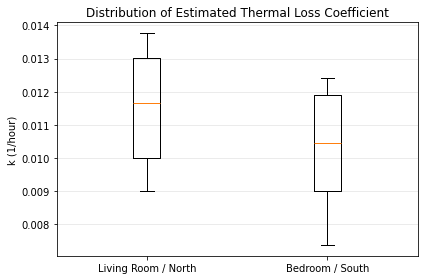

In [10]:
# Distribution of Cooling Rates
plt.figure(figsize=(6,4))
plt.boxplot(
    [north_k['k_1_per_h'].dropna(), south_k['k_1_per_h'].dropna()],
    tick_labels=['Living Room / North', 'Bedroom / South']
)
plt.title("Distribution of Estimated Thermal Loss Coefficient")
plt.ylabel("k (1/hour)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/02_ua_estimation/cooling_rates.png", dpi=300, facecolor='white')

The two zones exhibit similar distributions of k, with a slight shift toward higher values in the south-facing bedroom.

This difference is likely due to solar gains during the day, which influence nighttime cooling dynamics.

However, the overall similarity suggests a relatively uniform building envelope.

## 3. Estimate thermal loss characteristics (cooling rate and k coefficient)

The parameter k can be used to estimate the overall heat loss coefficient (UA) of the building:

$UA = k \cdot C$

where:
- UA (W/K) is the heat loss coefficient
- C (J/K) is the effective thermal capacity of the building

Assuming a typical thermal mass value per unit area, we can approximate C and compute UA.

This allows us to move from relative indicators (cooling rates) to absolute physical quantities that describe the building's thermal performance.

## 4. Physical Interpretation and Practical Relevance

The UA value provides a direct interpretation of heat losses.

For example:
- If indoor temperature is 20°C and outdoor temperature is 0°C → ΔT = 20°C
- If UA = 36 W/K, then heat losses are:

Q = UA · ΔT = 36 × 20 = 720 W

This means the building loses approximately 0.72 kW under these conditions.

Such estimates are directly useful for:
- sizing HVAC systems
- evaluating insulation improvements
- comparing energy performance across buildings

This approach demonstrates how real sensor data can be used to quantify thermal behavior and support data-driven energy decisions.

## Why This Matters

This analysis goes beyond simple monitoring.

By estimating cooling rates, thermal parameters, and heat loss coefficients from real measurements, it becomes possible to quantify building performance using data rather than assumptions.

This is a first step toward building a residential thermal digital twin, enabling simulation, optimization, and more advanced control strategies.

## From Model to Real-World Meaning

A rough estimation of UA can be obtained assuming a typical thermal capacity.
However, this introduces uncertainty, so results should be interpreted as indicative.

Assuming:
- Thermal capacity C ≈ 100,000 J/K (typical for this size apartment)
- k ≈ 0.011 1/hour

Then:
UA ≈ (k × C) / 3600 ≈ (0.011 × 100,000) / 3600 ≈ 0.31 W/K

For a temperature difference of 20°C:
Q = UA × ΔT ≈ 0.31 × 20 ≈ 6.2 W

## Relative Heat Loss Indicator
**Metric**

$Indicator = k \cdot (T_{in} - T_{out})$

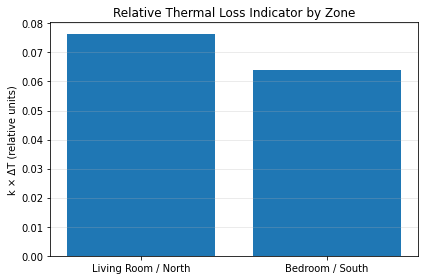

In [11]:
north_deltaT = (df_filtered['temp_salon_c'] - df_filtered['temp_out_1_b_c']).mean()
south_deltaT = (df_filtered['temp_kids_c'] - df_filtered['temp_out_2_n_c']).mean()

north_indicator = north_mean * north_deltaT
south_indicator = south_mean * south_deltaT

plt.figure(figsize=(6,4))
plt.bar(['Living Room / North', 'Bedroom / South'], [north_indicator, south_indicator])
plt.title("Relative Thermal Loss Indicator by Zone")
plt.ylabel("k × ΔT (relative units)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/02_ua_estimation/relative_losses.png", dpi=300, facecolor='white')

## Relative Thermal Loss Comparison

To better understand how each zone behaves in practice, we combine:

- the estimated thermal coefficient k
- the actual temperature difference between indoor and outdoor conditions

We define a simple indicator:

Indicator = k × (T_in - T_out)

This is not an absolute heat loss value, but a relative metric that allows comparison between zones.

Results show that the north-facing living room exhibits higher thermal losses, 
primarily due to larger temperature differences with the outdoor environment.

This suggests that interventions in this area (e.g. insulation, sealing) may have a higher impact.